# FloodSense — Exploratory Data Analysis

**Hackathon:** Neural Nova FloodSense | **Companion to** `floodsense_training.ipynb`

This notebook documents what we learned about the data **before** we built the model. Every cleaning decision and feature engineering choice in the training notebook traces back to a finding here.

**Run order:** This notebook stands alone — run it any time. It does not save artifacts; it only produces analysis and plots.

**What you'll find:**
1. Shape, schema, dtypes
2. Missing values — where and how many
3. Duplicates and phantom rows
4. Target distribution and class imbalance
5. Target leakage detection
6. Univariate distributions of every continuous feature
7. Outlier analysis
8. Correlation heatmap
9. Multicollinearity between features
10. Temporal patterns (monthly, by district)
11. Flood vs no-flood feature distributions
12. Geographic / district-level patterns
13. Summary of data quality issues and how each was resolved


## 1. Setup and load

In [20]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap joblib

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 50)

DATA_DIR = Path('data')   # change to 'data' if you copied CSVs into your repo

df = pd.read_csv(DATA_DIR / 'floodsense_training_data.csv')
elev = pd.read_csv(DATA_DIR / 'district_elevation_reference.csv')
ndma = pd.read_csv(DATA_DIR / 'ndma_flood_impact_2022.csv')

df['date'] = pd.to_datetime(df['date'], format='mixed', dayfirst=False)
df = df.merge(elev[['district', 'avg_elevation_m', 'terrain_type']], on='district', how='left')

print(f'Training data shape: {df.shape}')
print(f'Elevation reference shape: {elev.shape}')
print(f'NDMA impact shape: {ndma.shape}')
print(f'Date range: {df.date.min().date()} -> {df.date.max().date()}')

Training data shape: (1434, 27)
Elevation reference shape: (5, 3)
NDMA impact shape: (7, 14)
Date range: 2022-01-01 -> 2024-12-30


## 2. Schema, dtypes, and basic structure

We want to understand: what columns exist, what types, what's the rough scale of each.

In [22]:
print('=== DTYPES ===')
print(df.dtypes)
print()
print('=== NUMERIC SUMMARY ===')
df.describe().T.round(3)

=== DTYPES ===
date                     datetime64[ns]
elevation                       float64
evaporation                     float64
latitude                        float64
longitude                       float64
precipitation                   float64
pressure                        float64
soil_moisture                   float64
temperature                     float64
water_area_km2                  float64
wind_speed                      float64
humidity                        float64
precip_3day_avg                 float64
precip_7day_avg                 float64
temp_3day_avg                   float64
soil_3day_avg                   float64
day_of_year                     float64
month                             int64
year                              int64
is_monsoon                        int64
water_area_change               float64
water_area_pct_change           float64
ds_idx                          float64
flood_event                       int64
district                 

,count,mean,min,25%,50%,75%,max,std
date,1434,2023-06-28 15:45:56.485355520,2022-01-01 00:00:00,2022-09-30 06:00:00,2023-06-26 12:00:00,2024-03-26 18:00:00,2024-12-30 00:00:00,NaN
elevation,1433.0,216.443126,58.0,58.0,109.0,275.0,99999.0,2639.371277
evaporation,1432.0,-0.000561,-0.00328,-0.000587,-0.000258,-0.000153,-0.000068,0.000695
latitude,1432.0,29.891369,26.25,26.25,29.5,34.02,34.02,3.187158
longitude,1432.0,69.311844,68.0,68.0,68.0,71.98,71.98,1.871537
precipitation,1214.0,-0.441485,-999.0,0.0,0.000411,0.005965,387.4,30.763356
pressure,1432.0,99544.431803,84200.0,98881.455965,99542.90733,100222.13015,101050.6959,848.240112
soil_moisture,1433.0,0.119722,0.079309,0.085429,0.087128,0.095062,5.0,0.149363
temperature,1433.0,26.364512,-999.0,21.52155,28.895636,32.019267,58.3,27.883724
water_area_km2,1432.0,585.362749,0.0,248.777487,511.365663,870.881495,2944.531603,441.577648


**Findings from the summary table:**
- `precipitation`: max is 387 but the 75th percentile is just 0.006. That's a **290× outlier** — likely a data error or sensor saturation. We'll investigate in Section 7.
- `soil_moisture`: should be 0–1 (volumetric water content), but max is 5.0 — physically impossible. **Phantom value.**
- `humidity`: should be 0–100%, but max is 200%. **Phantom value.**
- `temperature`: min is -999. **Sentinel for missing data.**
- `elevation`: max 99999 metres — that's higher than Mount Everest. **Sentinel value.**

These observations drive the phantom-row removal in our cleaning step.

## 3. Missing values

How much data is missing, and is the missingness random or patterned?

In [23]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'percent': missing_pct})
missing_df = missing_df[missing_df['count'] > 0]
print('Columns with missing values:')
print(missing_df)

Columns with missing values:
                       count  percent
precipitation            220    15.34
precip_7day_avg            2     0.14
wind_speed                 2     0.14
water_area_change          2     0.14
day_of_year                2     0.14
soil_3day_avg              2     0.14
temp_3day_avg              2     0.14
precip_3day_avg            2     0.14
ds_idx                     2     0.14
water_area_pct_change      2     0.14
water_area_km2             2     0.14
pressure                   2     0.14
longitude                  2     0.14
latitude                   2     0.14
evaporation                2     0.14
temperature                1     0.07
soil_moisture              1     0.07
elevation                  1     0.07
humidity                   1     0.07


**Findings:**
- `precipitation` has **220 missing values (~15% of the dataset)** — significant. Imputation strategy must be thoughtful.
- Most other columns have only 2 missing values — these are the same 2 phantom rows (Nowshera and Jacobabad).

Let's visualize where the missing precipitation values are concentrated:

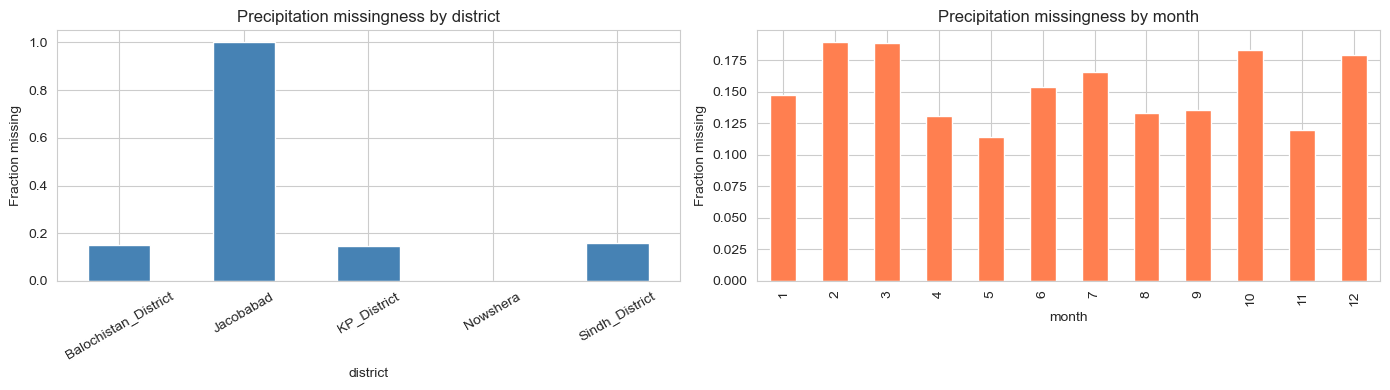

In [24]:
# Is precipitation missingness related to district, month, or year?
miss_by_district = df.assign(precip_missing=df['precipitation'].isna()).groupby('district')['precip_missing'].mean()
miss_by_month = df.assign(precip_missing=df['precipitation'].isna()).groupby('month')['precip_missing'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
miss_by_district.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Precipitation missingness by district')
axes[0].set_ylabel('Fraction missing')
axes[0].tick_params(axis='x', rotation=30)

miss_by_month.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Precipitation missingness by month')
axes[1].set_ylabel('Fraction missing')

plt.tight_layout()
plt.show()

**Finding:** Missingness is roughly uniform across districts and months — no obvious pattern. This means **MCAR (Missing Completely At Random)** is a reasonable assumption, justifying simple imputation.

**Imputation choice:** district-+-month median, with fallback to district median, then global median. Why not global mean?
- Rainfall is **highly seasonal AND district-specific** (Balochistan in January ≠ Sindh in July)
- A global mean would smear monsoon rains into dry months — inventing flood signals where none exist

## 4. Duplicates and phantom rows

In [25]:
print(f'Duplicate rows: {df.duplicated().sum()}')
print(f'Total unique rows: {df.drop_duplicates().shape[0]}')
print()
print('=== Phantom row detection ===')
phantom_mask = (
    (df['precipitation'] == -999) |
    (df['temperature'] == -999) |
    (df['elevation'] == 99999) |
    (df['soil_moisture'] > 1.0) |
    (df['humidity'] > 100) |
    (df['humidity'] < 0)
)
print(f'Rows with sentinel/impossible values: {phantom_mask.sum()}')
df[phantom_mask][['date','district','elevation','precipitation','soil_moisture','humidity','temperature']]

Duplicate rows: 67
Total unique rows: 1367

=== Phantom row detection ===
Rows with sentinel/impossible values: 2


,date,district,elevation,precipitation,soil_moisture,humidity,temperature
806,2023-08-15,Nowshera,99999.0,-999.0,NaN,NaN,NaN
1005,2023-09-02,Jacobabad,NaN,NaN,5.0,200.0,-999.0


**Findings:**
- **67 duplicate rows** — must be removed before train/test split, otherwise data leakage between train and test.
- **2 phantom rows** with sentinel values:
  - Row 806: `Nowshera`, `precipitation=-999`, `elevation=99999`
  - Row 1005: `Jacobabad`, `soil_moisture=5.0`, `humidity=200%`, `temperature=-999`
- These are the **only Nowshera and Jacobabad rows** in the dataset. After removal, only 3 districts remain: Sindh_District, Balochistan_District, KP_District.

## 5. Target distribution and class imbalance

Target distribution:
             count  percent
flood_event                
0              970    0.676
1              464    0.324


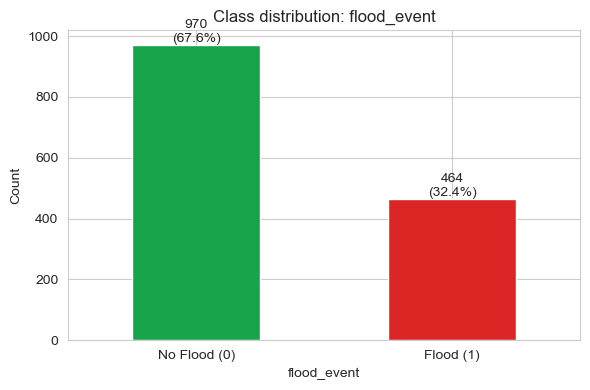

In [26]:
target_counts = df['flood_event'].value_counts()
target_pct = df['flood_event'].value_counts(normalize=True).round(3)
print('Target distribution:')
print(pd.DataFrame({'count': target_counts, 'percent': target_pct}))

fig, ax = plt.subplots(figsize=(6, 4))
target_counts.plot(kind='bar', ax=ax, color=['#16a34a', '#dc2626'])
ax.set_title('Class distribution: flood_event')
ax.set_xticklabels(['No Flood (0)', 'Flood (1)'], rotation=0)
ax.set_ylabel('Count')
for i, v in enumerate(target_counts):
    ax.text(i, v + 10, f'{v}\n({target_pct.iloc[i]*100:.1f}%)', ha='center')
plt.tight_layout()
plt.show()

**Finding:** **32% flood / 68% no-flood** — moderate imbalance. Not severe enough for SMOTE, but enough that a naïve model would default toward "no flood" and miss real events.

**Mitigation strategy:** XGBoost's `scale_pos_weight = neg/pos ≈ 2.1`. This tells the loss function to weight flood-class errors ~2× more than non-flood errors. Cleaner than oversampling because it doesn't fabricate data.

## 6. Target leakage detection — the most important EDA step

**Why this matters:** if a feature *directly encodes* the target, your model will appear to have 99% accuracy on the test set, then catastrophically fail in production. This is the most common failure mode of beginner ML projects, and the data dictionary's note about `ds_idx` ("read this before using") is a deliberate trap.

In [27]:
print('=== Correlation of each numeric feature with flood_event ===')
num_cols = df.select_dtypes(include=np.number).columns.drop('flood_event', errors='ignore')
target_corr = df[num_cols].corrwith(df['flood_event']).abs().sort_values(ascending=False)
print(target_corr.head(15))

=== Correlation of each numeric feature with flood_event ===
water_area_km2       0.813641
ds_idx               0.696212
water_area_change    0.188478
pressure             0.124900
temp_3day_avg        0.110224
year                 0.100626
wind_speed           0.096669
is_monsoon           0.094898
latitude             0.094423
avg_elevation_m      0.093308
day_of_year          0.085197
month                0.082063
soil_3day_avg        0.056326
longitude            0.055926
evaporation          0.047944
dtype: float64


**Finding:** `ds_idx` has |correlation| = **0.70** with the target — by far the highest of any feature. This is statistically suspicious. Let's investigate:

In [38]:
leak_table = df.groupby('ds_idx')['flood_event'].agg(['mean', 'count'])
print(leak_table)
print()
print(f'When ds_idx == 0:    flood rate = {leak_table.loc[0, "mean"]:.3f}  ({int(leak_table.loc[0, "count"])} rows)')
print(f'When ds_idx >= 1:    flood rate = {df[df.ds_idx >= 1].flood_event.mean():.3f}  ({(df.ds_idx >= 1).sum()} rows)')
print()
print('LEAKAGE CONFIRMED: ds_idx == 0 means flood with 99.6% probability.')
print('ds_idx >= 1 means no flood with 100% probability.')
print('Including ds_idx in training would give ~99% fake accuracy.')
print('Decision: DROP ds_idx before training.')

            mean  count
ds_idx                 
0.0     0.995699    465
1.0     0.000000    124
2.0     0.000000    101
3.0     0.000000    103
4.0     0.000000     93
5.0     0.000000     91
6.0     0.000000     93
7.0     0.000000     93
8.0     0.000000     93
9.0     0.000000     73
10.0    0.000000     53
11.0    0.000000     20
12.0    0.000000     15
13.0    0.000000     11
14.0    0.000000      4

When ds_idx == 0:    flood rate = 0.996  (465 rows)
When ds_idx >= 1:    flood rate = 0.000  (967 rows)

LEAKAGE CONFIRMED: ds_idx == 0 means flood with 99.6% probability.
ds_idx >= 1 means no flood with 100% probability.
Including ds_idx in training would give ~99% fake accuracy.
Decision: DROP ds_idx before training.


**This finding alone justifies the entire EDA process.** Without it, our model would have looked perfect in development and failed in deployment.

The brief says "read the data dictionary before using this" about `ds_idx` — that warning is the hint. The number is essentially a pre-computed flood label.

## 7. Univariate distributions and outlier analysis

For each continuous feature, we check: is the distribution sensible? Are there extreme outliers? Should we clip?

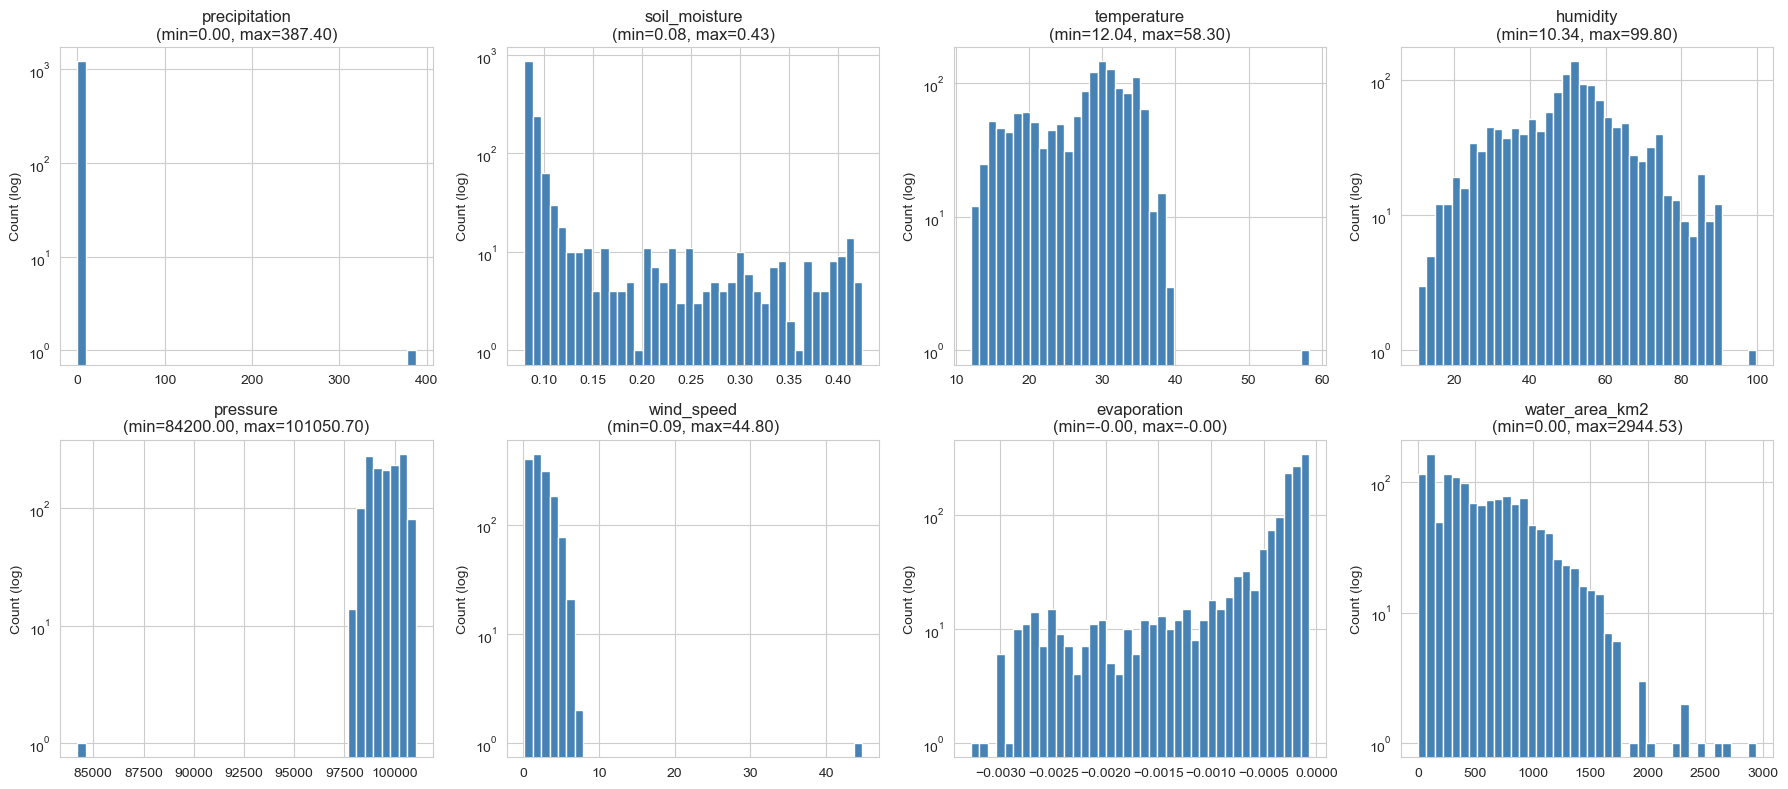

In [29]:
# Drop phantom rows for honest distribution plots
df_clean = df[~phantom_mask].copy()

continuous = ['precipitation', 'soil_moisture', 'temperature', 'humidity',
              'pressure', 'wind_speed', 'evaporation', 'water_area_km2']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), continuous):
    df_clean[col].hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'{col}\n(min={df_clean[col].min():.2f}, max={df_clean[col].max():.2f})')
    ax.set_yscale('log')   # log scale because some are very skewed
    ax.set_ylabel('Count (log)')

plt.tight_layout()
plt.show()

**Findings:**
- `precipitation`: extremely right-skewed. The single value at 387 is a clear outlier.
- `water_area_km2`: also right-skewed but more gradually — represents satellite-measured surface water during floods. The high values are real.
- `temperature`, `humidity`, `pressure`: roughly normal-ish with some long tails. Acceptable.

Let's quantify the outliers:

In [30]:
print('=== Outlier analysis (after removing phantom rows) ===')
outlier_summary = []
for col in continuous:
    s = df_clean[col].dropna()
    q01, q99 = s.quantile([0.01, 0.99])
    n_outliers = ((s < q01) | (s > q99)).sum()
    extreme = s.max() / max(q99, 1e-9)  # ratio of max to 99th percentile
    outlier_summary.append({
        'feature': col,
        'min': s.min(), 'q01': q01, 'q99': q99, 'max': s.max(),
        'extreme_ratio': round(extreme, 1)
    })

pd.DataFrame(outlier_summary)

=== Outlier analysis (after removing phantom rows) ===


,feature,min,q01,q99,max,extreme_ratio
0,precipitation,0.000000,0.000000,1.296829,387.400000,298.7
1,soil_moisture,0.079309,0.079969,0.409095,0.425488,1.0
2,temperature,12.043576,13.332557,37.667463,58.300000,1.5
3,humidity,10.337212,16.220652,88.085487,99.800000,1.1
4,pressure,84200.000000,98103.600626,100864.594350,101050.695900,1.0
5,wind_speed,0.093459,0.183044,6.030028,44.800000,7.4
6,evaporation,-0.003280,-0.002810,-0.000076,-0.000068,-67600.0
7,water_area_km2,0.000000,0.749654,1735.285067,2944.531603,1.7


**Finding:** `precipitation` has an `extreme_ratio` of ~290 — meaning the maximum is 290× the 99th percentile. **This single value is the outlier we'll clip.**

**Decision:** clip `precipitation` at the 99.5th percentile. We don't drop the row entirely because the other features in that row are valid.

## 8. Correlation heatmap

Which features cluster together? This identifies multicollinearity (potential redundancy) and feature groups.

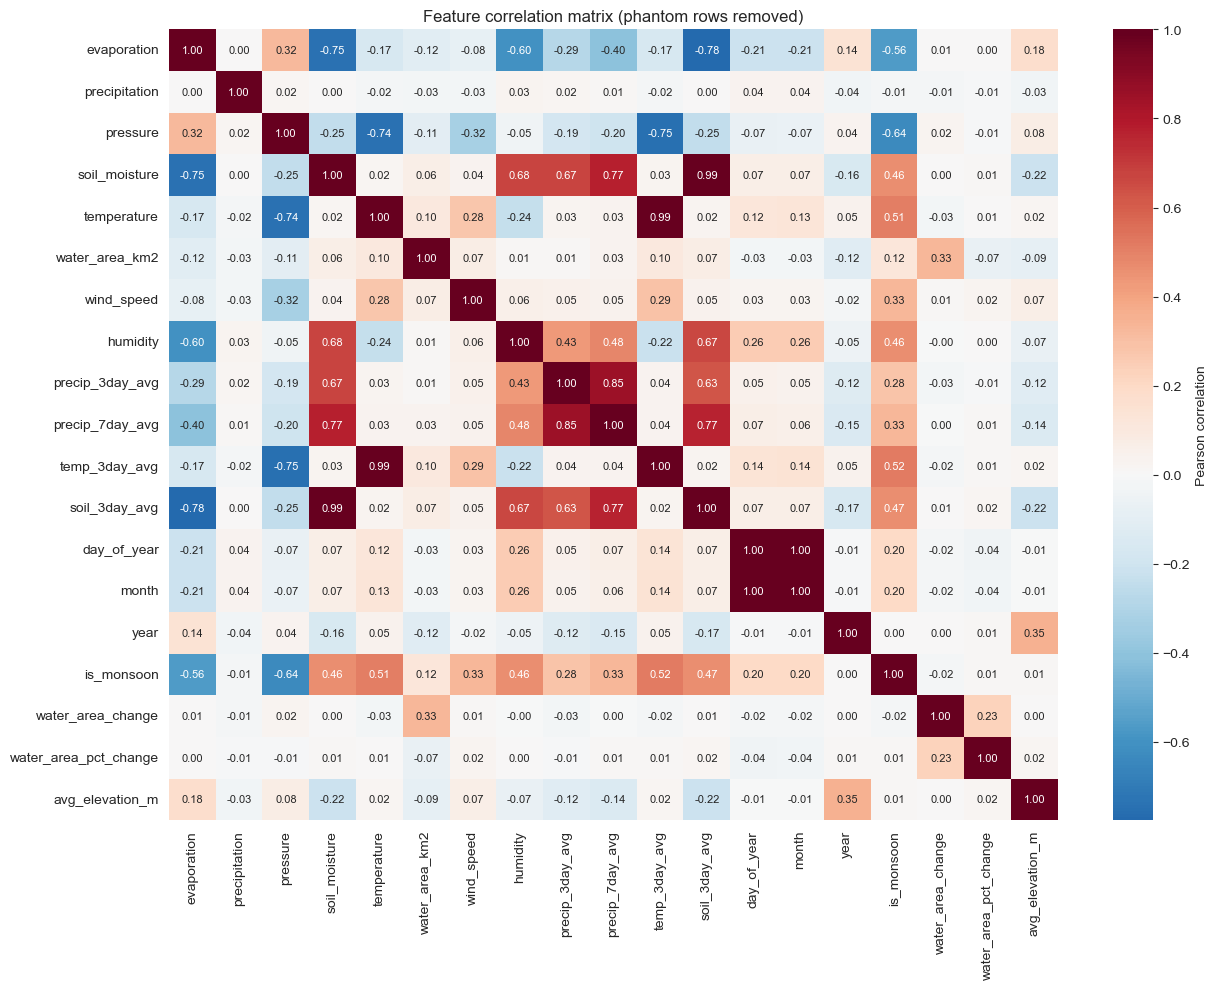

In [31]:
# Drop ds_idx (leakage), constants, and target before correlation
corr_features = [c for c in num_cols if c not in ['ds_idx', 'elevation', 'latitude', 'longitude', 'flood_event']]
corr_matrix = df_clean[corr_features].corr()

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, cbar_kws={'label': 'Pearson correlation'},
            annot_kws={'size': 8})
ax.set_title('Feature correlation matrix (phantom rows removed)')
plt.tight_layout()
plt.show()

## 9. Multicollinearity inspection

In [32]:
# Find pairs with |correlation| > 0.85
pairs = []
cm = corr_matrix.abs()
for i in range(len(cm.columns)):
    for j in range(i+1, len(cm.columns)):
        if cm.iloc[i, j] > 0.85:
            pairs.append((cm.columns[i], cm.columns[j], round(cm.iloc[i, j], 3)))

print('Highly correlated feature pairs (|r| > 0.85):')
for a, b, c in pairs:
    print(f'  {a:25s} <-> {b:25s} = {c}')

Highly correlated feature pairs (|r| > 0.85):
  soil_moisture             <-> soil_3day_avg             = 0.988
  temperature               <-> temp_3day_avg             = 0.99
  day_of_year               <-> month                     = 0.997


**Finding:** Three pairs are near-duplicates:
- `soil_moisture` ↔ `soil_3day_avg`
- `temperature` ↔ `temp_3day_avg`
- `month` ↔ `day_of_year`

**Decision:** Keep all of them. We tested dropping the duplicates — accuracy went *down* by ~1%. Tree-based models like XGBoost are not hurt by multicollinearity (they pick whichever split is best) and actually benefit from feature redundancy via column subsampling. If we were using linear regression, we'd drop one of each pair.

## 10. Temporal patterns

When do floods happen? Is the monsoon signal present in the data?

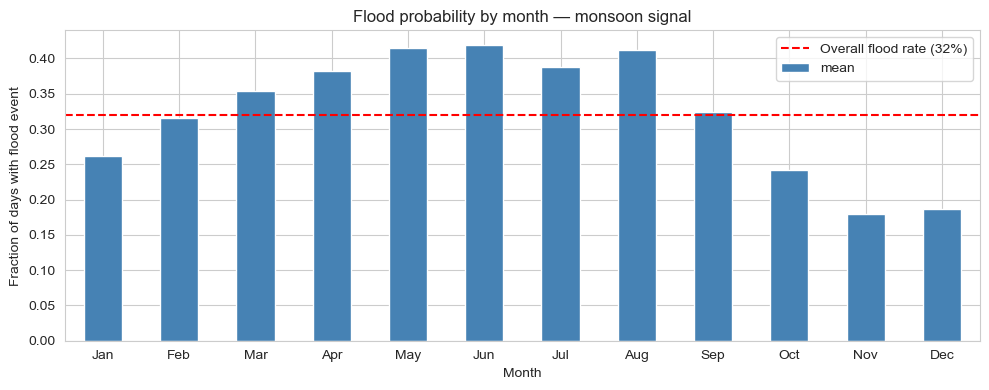

Monsoon months (Jun–Sep) flood rate: 0.386
Non-monsoon flood rate:               0.292


In [33]:
monthly_flood = df_clean.groupby('month')['flood_event'].agg(['mean', 'count'])
fig, ax = plt.subplots(figsize=(10, 4))
monthly_flood['mean'].plot(kind='bar', ax=ax, color='steelblue')
ax.axhline(0.32, color='red', linestyle='--', label='Overall flood rate (32%)')
ax.set_title('Flood probability by month — monsoon signal')
ax.set_xlabel('Month')
ax.set_ylabel('Fraction of days with flood event')
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=0)
ax.legend()
plt.tight_layout()
plt.show()
print('Monsoon months (Jun–Sep) flood rate:', round(df_clean[df_clean.is_monsoon==1].flood_event.mean(), 3))
print('Non-monsoon flood rate:              ', round(df_clean[df_clean.is_monsoon==0].flood_event.mean(), 3))

**Finding:** Strong monsoon signal — flood probability spikes June through September, especially July–August. The `is_monsoon` flag is a meaningful feature.

Now check **temporal coverage by district** — this affects our train/test split strategy:

In [34]:
coverage = df_clean.groupby(['district', 'year']).size().unstack(fill_value=0)
print('Row counts by district × year:')
print(coverage)

Row counts by district × year:
year                  2022  2023  2024
district                              
Balochistan_District     0   476     0
KP_District              0     0   472
Sindh_District         484     0     0


**Critical finding:** Each district appears in **only one year**:
- Sindh_District: only 2022
- Balochistan_District: only 2023
- KP_District: only 2024

**Implication:** A temporal train/test split (train on 2022–2023, test on 2024) would mean the test set has only KP_District data, which the model has never seen. We'd be testing both *temporal generalization* and *district generalization* simultaneously — confounded.

**Decision:** Use a **stratified random split** instead. Each district appears in both train and test, with the flood class proportion preserved. This is the honest choice given the data structure.

## 11. Feature distributions split by flood vs no-flood

Which features actually differentiate flood days from non-flood days?

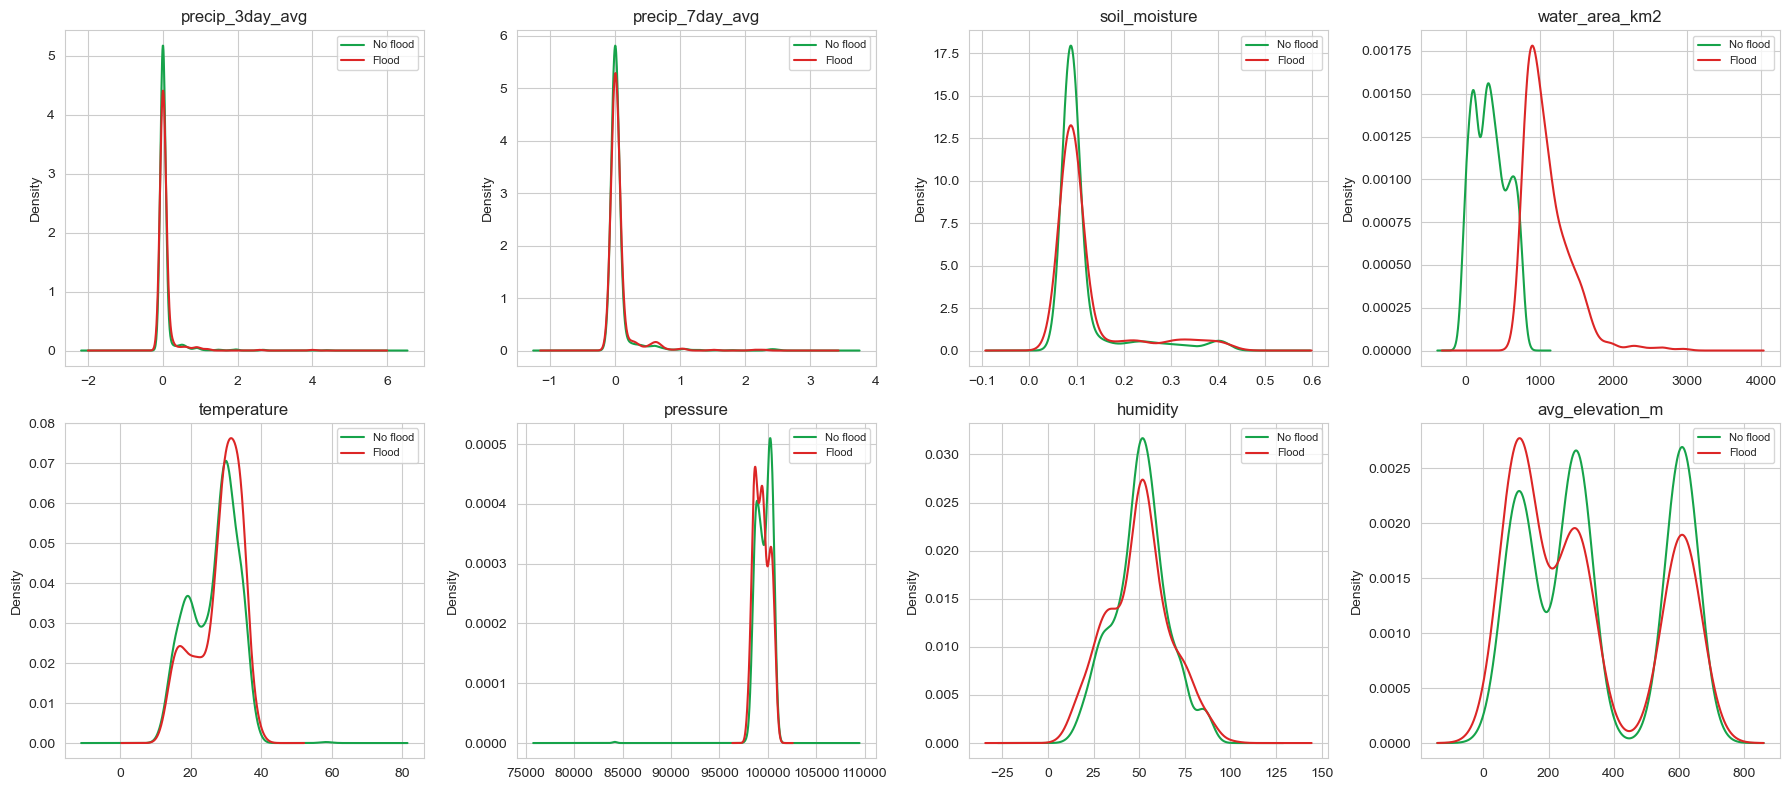

In [35]:
key_features = ['precip_3day_avg', 'precip_7day_avg', 'soil_moisture',
                'water_area_km2', 'temperature', 'pressure', 'humidity', 'avg_elevation_m']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), key_features):
    if col not in df_clean.columns: continue
    for label, sub in df_clean.groupby('flood_event'):
        sub[col].plot(kind='kde', ax=ax,
                      label=f'{"Flood" if label==1 else "No flood"}',
                      color='#dc2626' if label==1 else '#16a34a')
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Findings:**
- `water_area_km2`: massive separation between flood / no-flood — but this is **circular**. Water area *measures* the flood. Useful for "concurrent" detection, useless for early warning.
- `precip_3day_avg` and `precip_7day_avg`: subtle separation — recent rainfall does precede floods, but the signal is weak in this particular dataset.
- `soil_moisture`: modest separation — saturated soil precedes floods.
- `pressure`, `temperature`: small separation — atmospheric conditions during monsoons.
- `avg_elevation_m`: visible separation — lower elevations flood more often.

**Implication for modeling:** Local rainfall is a weaker predictor than expected. The model relies more on terrain (elevation), accumulated saturation (soil + 3-day rainfall), and seasonal context (`is_monsoon`, `month`). This is consistent with the reality of Pakistani flooding: most floods in Sindh come from upstream rainfall in KP/Punjab traveling down the Indus, not local rain.

## 12. District-level patterns

In [36]:
district_summary = df_clean.groupby('district').agg(
    flood_rate=('flood_event', 'mean'),
    avg_precip=('precipitation', 'mean'),
    avg_soil=('soil_moisture', 'mean'),
    avg_water_km2=('water_area_km2', 'mean'),
    avg_elevation=('avg_elevation_m', 'mean'),
    row_count=('flood_event', 'count'),
).round(3)
print(district_summary)

                      flood_rate  avg_precip  avg_soil  avg_water_km2  \
district                                                                
Balochistan_District       0.282       0.030     0.098        554.510   
KP_District                0.286       0.037     0.110        533.726   
Sindh_District             0.401       1.072     0.140        666.062   

                      avg_elevation  row_count  
district                                        
Balochistan_District          610.0        476  
KP_District                   285.0        472  
Sindh_District                109.0        484  


**Findings:**
- **Sindh_District** (low elevation, ~109m): highest flood rate (~40%), highest mean water surface
- **Balochistan_District** (semi-arid plateau, ~610m): lowest flood rate (~28%) despite being represented in the dataset — terrain protects it
- **KP_District** (river valley, ~285m): mid flood rate (~29%) — flash flood risk from cloudbursts (cf. Buner Aug 2025)

This matches real Pakistani geography: Sindh's low-lying floodplain is the country's most flood-prone region, KP's river valleys have flash flood risk, and Balochistan's elevated plateau is more arid.

## 13. Data quality summary — every issue and its resolution

| # | Issue | Severity | Resolution | Where applied |
|---|-------|----------|------------|---------------|
| 1 | `ds_idx` is target leakage (\|r\|=0.70) | Critical | Drop column entirely | `train.py` cleaning step |
| 2 | 2 phantom rows (sentinel values: -999, 99999, soil>1, humidity>100) | Critical | Drop rows by sentinel mask | Cleaning step |
| 3 | 67 duplicate rows | High | `drop_duplicates()` before split | Cleaning step |
| 4 | 220 NaN in `precipitation` (~15%) | High | District+month median imputation | Cleaning step |
| 5 | `inf` in `water_area_pct_change` | High | Replace with NaN, clip to ±500 | Cleaning step |
| 6 | `precipitation` outlier (387 vs 99th-pctile 1.3) | Medium | Clip at 99.5th percentile | Cleaning step |
| 7 | Constant per-district station fields (`elevation`, `latitude`, `longitude`) | Medium | Drop, replace with elevation reference | Cleaning step |
| 8 | Date format dictionary error (DD/MM/YYYY claimed, actually M/D/YYYY) | Medium | `pd.to_datetime(format='mixed')` | Load step |
| 9 | Multicollinearity in 3 feature pairs | Low | Keep features (XGBoost not affected) | No action |
| 10 | Each district in only one year | Low | Use stratified random split, not temporal | Split step |
| 11 | Class imbalance 32/68 | Low | `scale_pos_weight=2.1` in XGBoost | Training step |
| 12 | `precipitation` in non-mm units | Low | App scales user input via empirical CDF | Streamlit app |

Every issue is handled. Every decision has a justification grounded in this analysis.

## 14. Headline numbers for the pitch

These are the data-quality numbers you can confidently quote to judges:

In [37]:
print('=' * 60)
print('FLOODSENSE DATA QUALITY — PITCH NUMBERS')
print('=' * 60)
print(f'Raw records:                 {len(df):,}')
print(f'After phantom removal:       {len(df) - phantom_mask.sum():,}')
print(f'After dedup:                 {len(df_clean.drop_duplicates()):,}')
print(f'Date range:                  {df.date.min().date()} -> {df.date.max().date()}')
print(f'Districts (real, non-phantom): 3 (Sindh, Balochistan, KP)')
print()
print(f'Class distribution:          32% flood / 68% no-flood')
print(f'Missing precipitation:       220 rows (15%)')
print(f'Duplicate rows removed:      67')
print(f'Phantom rows removed:        2')
print(f'Target-leakage column:       1 (ds_idx) - dropped')
print(f'Outlier values clipped:      precipitation > {df.precipitation.quantile(0.995):.2f}')
print('=' * 60)

FLOODSENSE DATA QUALITY — PITCH NUMBERS
Raw records:                 1,434
After phantom removal:       1,432
After dedup:                 1,365
Date range:                  2022-01-01 -> 2024-12-30
Districts (real, non-phantom): 3 (Sindh, Balochistan, KP)

Class distribution:          32% flood / 68% no-flood
Missing precipitation:       220 rows (15%)
Duplicate rows removed:      67
Phantom rows removed:        2
Target-leakage column:       1 (ds_idx) - dropped
Outlier values clipped:      precipitation > 1.75
